
=== ROUTE SUMMARY ===
Start: floor 1, cell (32, 54)
Goal : floor 1, room 10.1.17, cell (24, 32)
Accessible mode: True
Steps: 30
Distance: 24.0 m
Walking time: 0.31 min
Compute time: 0.0006 s

=== ROUTE INSTRUCTIONS ===
- Go Left for 22 steps
- Go Up for 8 steps


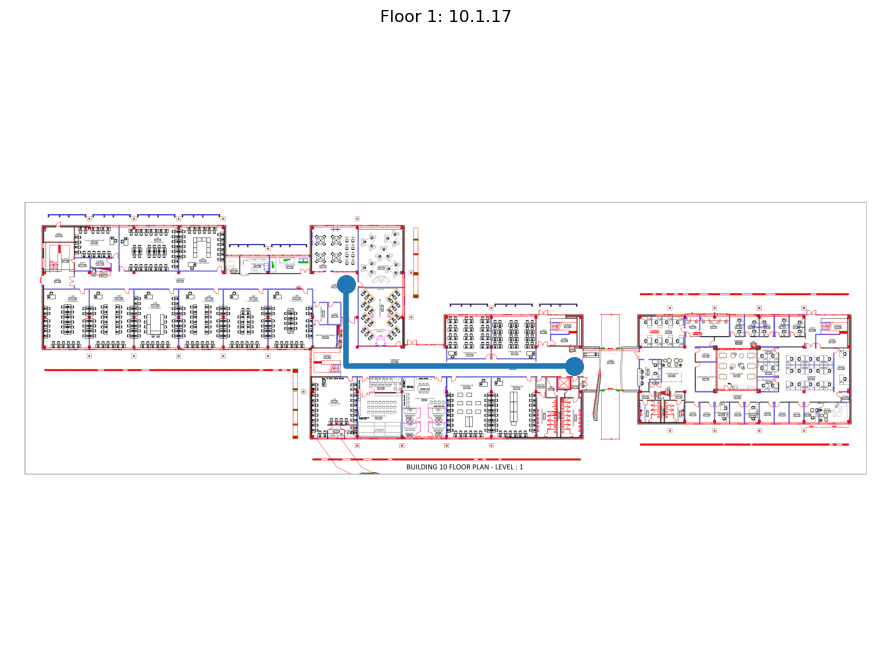


=== ROUTE SUMMARY (MULTI-FLOOR) ===
Start: floor 1, cell (32, 54)
Goal : floor 2, room 10.2.63, cell (44, 111)
Accessible mode: True
Connector used: elevator elevator1 -> elevator2
Steps (walking): 43
Distance (walking): 34.4 m
Walking time: 0.44 min
Transfer time: 20 s
ETA total: 0.77 min

=== ROUTE INSTRUCTIONS (PART 1) ===
- Go Left for 1 steps

=== TRANSITION ===
- Take elevator from floor 1 to floor 2

=== ROUTE INSTRUCTIONS (PART 2) ===
- Go Right for 20 steps
- Go Up for 2 steps
- Go Right for 1 steps
- Go Up for 1 steps
- Go Right for 12 steps
- Go Down for 2 steps
- Go Right for 4 steps


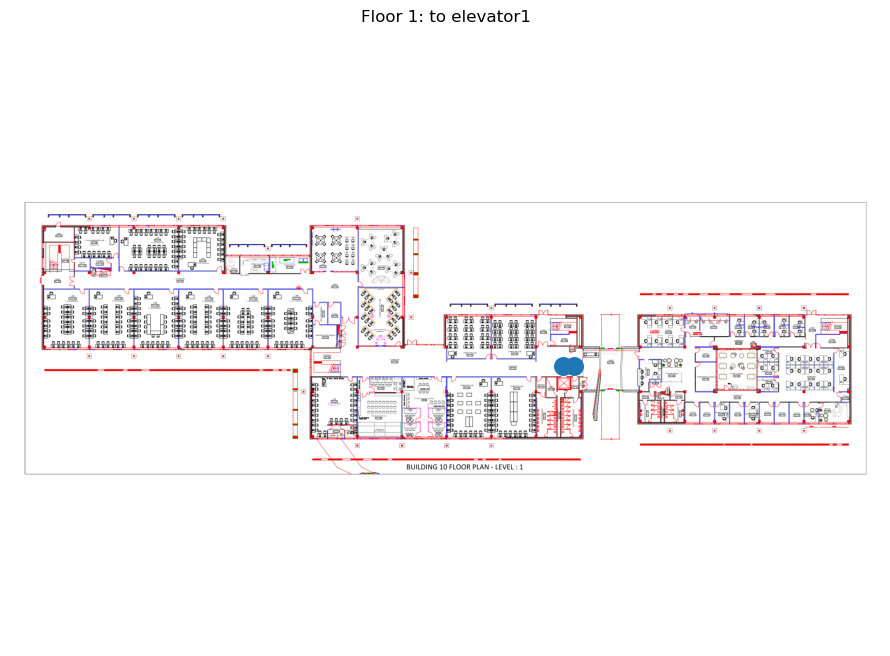

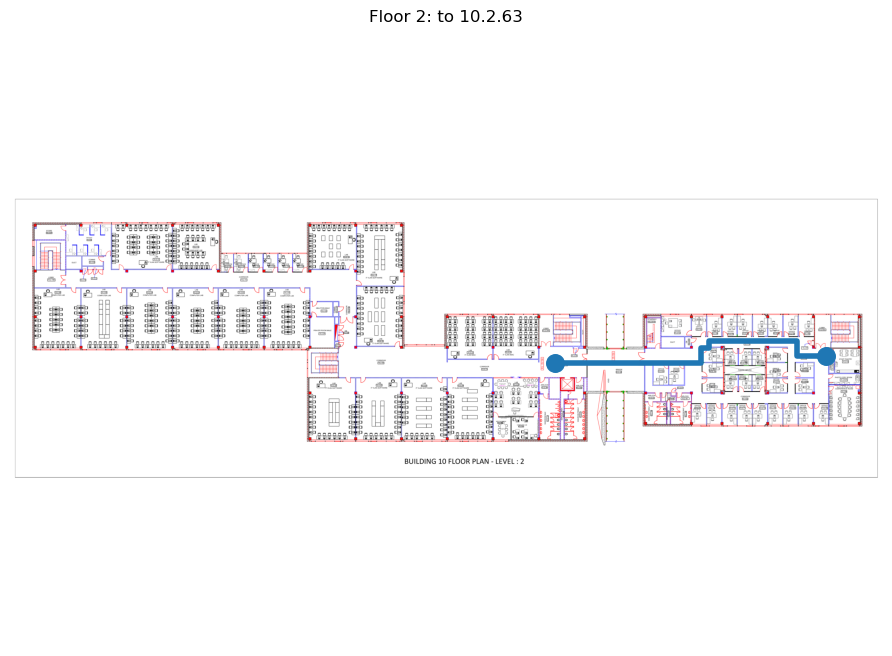

In [1]:
# routing_engine.py
# Expected files in the SAME folder:
#   - navigation_masks_manifest (1).json
#   - navigation_masks_manifest (2).json   (new, may contain only floor 2)  :contentReference[oaicite:2]{index=2}
#   - floor_data.json                      (floor 1)
#   - floor2_data.json                     (floor 2)                      :contentReference[oaicite:3]{index=3}
#   - inv_walkable_route_floor_1.jpeg
#   - inv_walkable_route_floor_2.png       (your real floor 2 mask)
#   - final_data (1).csv                   (optional playback)
#   - B10  Level 1 Floor_Plan.pdf          (optional visualization)
#   - B10  Level 2 Floor_Plan.pdf          (optional visualization)

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
import json
import math
import heapq
import time
import re

import numpy as np
from PIL import Image

# Optional visualization (overlay route on floor plan PDFs)
try:
    import fitz  # pymupdf
    import matplotlib.pyplot as plt
    HAS_VIZ = True
except Exception:
    HAS_VIZ = False


# ----------------------------
# CONFIG
# ----------------------------
BASE_DIR = Path.cwd()

MANIFEST_CANDIDATES = [
    "navigation_masks_manifest (1).json",
    "navigation_masks_manifest (2).json",
]

FLOOR1_DATA_NAME = "floor_data.json"
FLOOR2_DATA_NAME = "floor2_data.json"

# Walkable images (we will auto-find if these names are missing)
WALKABLE_HINTS = {
    1: ["inv_walkable_route_floor_1.jpeg", "walkable routes floor1.jpeg", "floor_1", "level1"],
    2: ["inv_walkable_route_floor_2.png", "floor_2", "level2"],
}

# Floor plan PDFs (optional, only if visualize=True)
PDF_HINTS = {
    1: ["B10  Level 1 Floor_Plan.pdf", "Level 1", "level1"],
    2: ["B10  Level 2 Floor_Plan.pdf", "Level 2", "level2"],
}

# Distance + time assumptions
METERS_PER_GRID_STEP = 0.8   # each move to adjacent cell
WALK_SPEED_M_PER_S = 1.3     # average walking speed

# Vertical transition penalty (time only, distance stays walking-only)
TRANSFER_TIME_S = {
    "elevator": 20.0,
    "stairway": 35.0,
}


# ----------------------------
# IO helpers
# ----------------------------
def load_json(path: Path) -> Any:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def find_first_existing(base: Path, exact_first: List[str], fallback_keywords: List[str], exts: Tuple[str,...]) -> Optional[Path]:
    # 1) exact names
    for name in exact_first:
        p = base / name
        if p.exists():
            return p

    # 2) keyword scan
    files = []
    for ext in exts:
        files.extend(base.glob(f"*{ext}"))

    kws = [k.lower() for k in fallback_keywords]
    for p in files:
        low = p.name.lower()
        if all(kw in low for kw in kws if kw not in ["level1","level2","floor_1","floor_2"]):
            return p

    # 3) looser: any file containing any keyword
    for p in files:
        low = p.name.lower()
        if any(kw in low for kw in kws):
            return p

    return None


# ----------------------------
# Manifest parsing
# ----------------------------
def merge_manifests(base: Path) -> List[dict]:
    all_entries: List[dict] = []
    for name in MANIFEST_CANDIDATES:
        p = base / name
        if not p.exists():
            continue
        obj = load_json(p)
        if isinstance(obj, list):
            all_entries.extend([x for x in obj if isinstance(x, dict)])
        elif isinstance(obj, dict):
            floors = obj.get("floors", obj)
            if isinstance(floors, list):
                all_entries.extend([x for x in floors if isinstance(x, dict)])
            elif isinstance(floors, dict):
                for _, v in floors.items():
                    if isinstance(v, dict):
                        all_entries.append(v)
    return all_entries

def floor_from_manifest_item(item: dict) -> Optional[int]:
    # try explicit key
    if "floor" in item:
        try:
            return int(item["floor"])
        except Exception:
            pass
    # parse from floor_plan text
    fp = str(item.get("floor_plan", "")).lower()
    if "level1" in fp or "level 1" in fp:
        return 1
    if "level2" in fp or "level 2" in fp:
        return 2
    return None

def pick_floor_meta(manifest_entries: List[dict], floor: int) -> Optional[dict]:
    # direct match
    for it in manifest_entries:
        f = floor_from_manifest_item(it)
        if f == floor:
            return it
    # fallback by scanning strings
    key = f"level{floor}"
    for it in manifest_entries:
        if key in str(it).lower():
            return it
    return None

def meta_origin_and_spacing(meta: dict, mask_w: int, mask_h: int) -> Tuple[float, float, float]:
    """
    Meta stores origin and spacing in the ORIGINAL floorplan image coordinate system.
    If the walkable image is resized, scale origin + spacing.
    """
    raw_w = float(meta.get("width", mask_w))
    raw_h = float(meta.get("height", mask_h))
    raw_spacing = float(meta.get("grid_spacing", 40))

    origin = meta.get("origin", {}) if isinstance(meta.get("origin"), dict) else {}
    raw_ox = float(origin.get("x", meta.get("origin_x", raw_w / 2)))
    raw_oy = float(origin.get("y", meta.get("origin_y", raw_h / 2)))

    sx = mask_w / raw_w if raw_w else 1.0
    sy = mask_h / raw_h if raw_h else 1.0
    s = (sx + sy) / 2.0

    ox = raw_ox * sx
    oy = raw_oy * sy
    spacing = raw_spacing * s
    return ox, oy, spacing


# ----------------------------
# Walkable mask -> grid
# ----------------------------
def load_walkable_boolean(path: Path) -> np.ndarray:
    """
    Auto-detect whether corridors are WHITE-on-BLACK or BLACK-on-WHITE.
    """
    img = Image.open(path).convert("L")
    arr = np.array(img)
    frac_white = float((arr > 200).mean())
    if frac_white > 0.60:
        return arr < 128
    return arr > 127

def build_grid_from_walkable(walkable_mask: np.ndarray, grid_spacing_px: float) -> np.ndarray:
    H, W = walkable_mask.shape
    gs = max(1, int(round(grid_spacing_px)))
    gw = int(math.ceil(W / gs))
    gh = int(math.ceil(H / gs))

    grid = np.zeros((gh, gw), dtype=bool)
    for gy in range(gh):
        for gx in range(gw):
            px = min(W - 1, int(gx * gs + gs / 2))
            py = min(H - 1, int(gy * gs + gs / 2))
            grid[gy, gx] = bool(walkable_mask[py, px])
    return grid

def nearest_free_cell(grid: np.ndarray, gy: int, gx: int, r: int = 60) -> Optional[Tuple[int, int]]:
    if 0 <= gy < grid.shape[0] and 0 <= gx < grid.shape[1] and grid[gy, gx]:
        return (gy, gx)
    for rr in range(1, r + 1):
        for dy in range(-rr, rr + 1):
            for dx in range(-rr, rr + 1):
                ny, nx = gy + dy, gx + dx
                if 0 <= ny < grid.shape[0] and 0 <= nx < grid.shape[1] and grid[ny, nx]:
                    return (ny, nx)
    return None


# ----------------------------
# A* pathfinding
# ----------------------------
def neighbors_4(grid: np.ndarray, s: Tuple[int, int]):
    y, x = s
    for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
        ny, nx = y + dy, x + dx
        if 0 <= ny < grid.shape[0] and 0 <= nx < grid.shape[1] and grid[ny, nx]:
            yield (ny, nx)

def manhattan(a: Tuple[int, int], b: Tuple[int, int]) -> int:
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def astar(grid: np.ndarray, start: Tuple[int, int], goal: Tuple[int, int]) -> Optional[List[Tuple[int, int]]]:
    if start is None or goal is None:
        return None
    if not grid[start] or not grid[goal]:
        return None

    open_heap = []
    heapq.heappush(open_heap, (0, start))
    came_from: Dict[Tuple[int,int], Tuple[int,int]] = {}
    g_score = {start: 0}

    while open_heap:
        _, current = heapq.heappop(open_heap)
        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for nb in neighbors_4(grid, current):
            tentative = g_score[current] + 1
            if nb not in g_score or tentative < g_score[nb]:
                g_score[nb] = tentative
                f = tentative + manhattan(nb, goal)
                heapq.heappush(open_heap, (f, nb))
                came_from[nb] = current

    return None


# ----------------------------
# Route instructions
# ----------------------------
DIRS = {(0, 1): "Right", (0,-1): "Left", (1, 0): "Down", (-1,0): "Up"}

def path_to_instructions(path: List[Tuple[int,int]]) -> List[str]:
    if not path or len(path) < 2:
        return ["You are already at the destination."]

    instructions = []
    run_dir = None
    run_len = 0

    def flush():
        nonlocal run_dir, run_len
        if run_dir is not None and run_len > 0:
            instructions.append(f"Go {run_dir} for {run_len} steps")
        run_dir = None
        run_len = 0

    for i in range(1, len(path)):
        y0, x0 = path[i-1]
        y1, x1 = path[i]
        dy, dx = (y1 - y0, x1 - x0)
        dname = DIRS.get((dy, dx), "Forward")
        if run_dir is None:
            run_dir = dname
            run_len = 1
        elif dname == run_dir:
            run_len += 1
        else:
            flush()
            run_dir = dname
            run_len = 1

    flush()
    return instructions


# ----------------------------
# Pose input
# ----------------------------
@dataclass
class Pose:
    x: float
    y: float
    floor: int


# ----------------------------
# Router
# ----------------------------
class B10Router:
    def __init__(self, base_dir: Path = BASE_DIR):
        self.base_dir = base_dir

        # Merge manifests (floor1 + floor2 metadata)
        self.manifest_entries = merge_manifests(base_dir)

        # Merge room data (floor1 + floor2)
        self.floor_data: List[dict] = []
        f1 = base_dir / FLOOR1_DATA_NAME
        if f1.exists():
            obj = load_json(f1)
            if isinstance(obj, list):
                self.floor_data.extend(obj)

        f2 = base_dir / FLOOR2_DATA_NAME
        if f2.exists():
            obj = load_json(f2)
            if isinstance(obj, list):
                self.floor_data.extend(obj)

        # room lookup
        self.room_by_id: Dict[str, dict] = {}
        for r in self.floor_data:
            if isinstance(r, dict) and r.get("room_id") is not None:
                self.room_by_id[str(r["room_id"]).strip()] = r

        # floor cache
        self._floor_loaded: Dict[int, bool] = {}
        self._walk_mask: Dict[int, np.ndarray] = {}
        self._grid: Dict[int, np.ndarray] = {}
        self._meta: Dict[int, dict] = {}
        self._origin_px: Dict[int, Tuple[float,float]] = {}
        self._spacing_px: Dict[int, float] = {}

        # Resolve walkable paths now (but load later)
        self.walkable_path: Dict[int, Path] = {}
        for fl in [1, 2]:
            p = find_first_existing(
                base_dir,
                exact_first=[WALKABLE_HINTS[fl][0]],
                fallback_keywords=WALKABLE_HINTS[fl][1:],
                exts=(".png", ".jpg", ".jpeg"),
            )
            if p is not None:
                self.walkable_path[fl] = p

        # Resolve PDFs for visualization (optional)
        self.pdf_path: Dict[int, Path] = {}
        for fl in [1, 2]:
            p = find_first_existing(
                base_dir,
                exact_first=[PDF_HINTS[fl][0]],
                fallback_keywords=PDF_HINTS[fl][1:],
                exts=(".pdf",),
            )
            if p is not None:
                self.pdf_path[fl] = p

    def ensure_floor_loaded(self, floor: int):
        if self._floor_loaded.get(floor):
            return

        if floor not in self.walkable_path:
            raise RuntimeError(f"No walkable mask found for floor {floor}. Put the floor {floor} walkable image in the folder.")

        walk_path = self.walkable_path[floor]
        walk_bool = load_walkable_boolean(walk_path)
        H, W = walk_bool.shape

        meta = pick_floor_meta(self.manifest_entries, floor)

        # If manifest for a floor is missing, fall back to center_x/center_y/grid_spacing from room data
        if meta is None:
            sample = None
            for r in self.floor_data:
                if str(r.get("floor")) == str(floor) and r.get("center_x") is not None and r.get("center_y") is not None:
                    sample = r
                    break
            if sample is None:
                raise RuntimeError(f"Missing manifest meta for floor {floor} and no center_x/center_y in room data.")
            meta = {
                "width": W,
                "height": H,
                "grid_spacing": float(sample.get("grid_spacing", 40)),
                "origin": {"x": float(sample["center_x"]), "y": float(sample["center_y"])},
                "floor_plan": str(sample.get("floor_plan", f"floor{floor}")),
            }

        ox, oy, spacing = meta_origin_and_spacing(meta, W, H)
        grid = build_grid_from_walkable(walk_bool, spacing)

        self._walk_mask[floor] = walk_bool
        self._grid[floor] = grid
        self._meta[floor] = meta
        self._origin_px[floor] = (ox, oy)
        self._spacing_px[floor] = spacing
        self._floor_loaded[floor] = True

    def steps_to_distance_time(self, steps: int) -> Tuple[float, float]:
        dist_m = steps * METERS_PER_GRID_STEP
        time_s = dist_m / WALK_SPEED_M_PER_S if WALK_SPEED_M_PER_S > 0 else 0.0
        return dist_m, time_s

    # ---- coordinate conversion ----
    def room_id_to_cell(self, room_id: str) -> Tuple[int, Tuple[int,int]]:
        rid = str(room_id).strip()
        if rid not in self.room_by_id:
            raise RuntimeError(f"Room id not found: {rid}")

        r = self.room_by_id[rid]
        floor = int(r["floor"])
        self.ensure_floor_loaded(floor)

        xg = float(r.get("x", 0.0))
        yg = float(r.get("y", 0.0))
        ox, oy = self._origin_px[floor]
        spacing = self._spacing_px[floor]

        px = ox + (xg * spacing)
        py = oy + (yg * spacing)

        gx = int(px // spacing)
        gy = int(py // spacing)

        snapped = nearest_free_cell(self._grid[floor], gy, gx, r=80)
        if snapped is None:
            raise RuntimeError(f"Room {rid} maps to blocked area on floor {floor}")
        return floor, snapped

    def pose_to_cell(self, pose: Pose) -> Tuple[int, Tuple[int,int]]:
        """
        Localization input is treated as GRID CELL indices:
          Pose(x=54, y=32, floor=1) -> cell (32,54)
        """
        floor = int(pose.floor)
        self.ensure_floor_loaded(floor)

        gy = int(round(pose.y))
        gx = int(round(pose.x))

        snapped = nearest_free_cell(self._grid[floor], gy, gx, r=100)
        if snapped is None:
            raise RuntimeError(f"Start pose maps to blocked area on floor {floor}.")
        return floor, snapped

    # ---- connectors ----
    def connectors_on_floor(self, floor: int, accessible_only: bool) -> List[dict]:
        conns = []
        for r in self.floor_data:
            if not isinstance(r, dict):
                continue
            if str(r.get("floor")) != str(floor):
                continue
            t = str(r.get("type", "")).lower()
            if t not in ["elevator", "stairway"]:
                continue
            if accessible_only:
                if t == "elevator" and bool(r.get("accessible", False)):
                    conns.append(r)
            else:
                conns.append(r)
        return conns

    def connector_key(self, conn: dict) -> str:
        """
        Build a normalized key so we can pair the same elevator/stair between floors when possible.
        Examples:
          elevator2 (floor 2) should pair with elevator2 (floor 1) if it exists.
        """
        rid = str(conn.get("room_id", "")).lower()
        typ = str(conn.get("type", "")).lower()
        digits = "".join(re.findall(r"\d+", rid))
        return f"{typ}:{digits}" if digits else f"{typ}:{rid}"

    # ---- visualize (optional) ----
    def visualize_path_on_floor(self, floor: int, path: List[Tuple[int,int]], title: str = ""):
        if not HAS_VIZ:
            print("[viz skipped] Install pymupdf + matplotlib to visualize.")
            return
        if floor not in self.pdf_path:
            print(f"[viz skipped] PDF not found for floor {floor}")
            return

        pdf_path = self.pdf_path[floor]
        doc = fitz.open(str(pdf_path))
        page = doc[0]
        pix = page.get_pixmap(matrix=fitz.Matrix(2, 2), alpha=False)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)
        doc.close()

        walk = self._walk_mask[floor]
        mask_h, mask_w = walk.shape
        img_h, img_w = img.shape[0], img.shape[1]
        sx = img_w / mask_w
        sy = img_h / mask_h

        spacing = self._spacing_px[floor]
        xs, ys = [], []
        for (gy, gx) in path:
            px = (gx * spacing + spacing / 2) * sx
            py = (gy * spacing + spacing / 2) * sy
            xs.append(px)
            ys.append(py)

        plt.figure(figsize=(14, 8))
        plt.imshow(img)
        plt.title(title or f"Floor {floor} route")
        plt.axis("off")
        plt.plot(xs, ys, linewidth=4)
        plt.scatter([xs[0], xs[-1]], [ys[0], ys[-1]], s=160)
        plt.show()

    # ---- main routing ----
    def route_pose_to_room(self, start_pose: Pose, goal_room_id: str, accessible: bool = True, visualize: bool = False) -> Dict[str, Any]:
        sf, s_cell = self.pose_to_cell(start_pose)
        gf, g_cell = self.room_id_to_cell(goal_room_id)

        # Same-floor
        if sf == gf:
            t0 = time.perf_counter()
            path = astar(self._grid[sf], s_cell, g_cell)
            t1 = time.perf_counter()
            if path is None:
                raise RuntimeError("No path found on same floor.")

            steps = len(path) - 1
            dist_m, walk_time_s = self.steps_to_distance_time(steps)
            instructions = path_to_instructions(path)

            print("\n=== ROUTE SUMMARY ===")
            print(f"Start: floor {sf}, cell {s_cell}")
            print(f"Goal : floor {gf}, room {goal_room_id}, cell {g_cell}")
            print(f"Accessible mode: {accessible}")
            print(f"Steps: {steps}")
            print(f"Distance: {dist_m:.1f} m")
            print(f"Walking time: {walk_time_s/60:.2f} min")
            print(f"Compute time: {(t1-t0):.4f} s")

            print("\n=== ROUTE INSTRUCTIONS ===")
            for line in instructions:
                print("-", line)

            if visualize:
                self.visualize_path_on_floor(sf, path, title=f"Floor {sf}: {goal_room_id}")

            return {
                "start_floor": sf,
                "goal_floor": gf,
                "path": path,
                "steps": steps,
                "distance_m": dist_m,
                "time_s": walk_time_s,
                "instructions": instructions,
            }

        # Multi-floor
        start_conns = self.connectors_on_floor(sf, accessible_only=accessible)
        goal_conns  = self.connectors_on_floor(gf, accessible_only=accessible)
        if not start_conns or not goal_conns:
            raise RuntimeError("No suitable connectors found (elevators/stairs).")

        # Prefer pairing by normalized key; fall back to all pairs by type.
        start_map: Dict[str, List[dict]] = {}
        goal_map: Dict[str, List[dict]] = {}
        for c in start_conns:
            start_map.setdefault(self.connector_key(c), []).append(c)
        for c in goal_conns:
            goal_map.setdefault(self.connector_key(c), []).append(c)

        candidate_pairs = []

        # 1) exact key matches (preferred)
        for k in start_map.keys():
            if k in goal_map:
                for a in start_map[k]:
                    for b in goal_map[k]:
                        candidate_pairs.append((a, b))

        # 2) fallback: same type pairs
        if not candidate_pairs:
            for a in start_conns:
                for b in goal_conns:
                    if str(a.get("type","")).lower() == str(b.get("type","")).lower():
                        candidate_pairs.append((a, b))

        best = None
        best_time = float("inf")
        best_dist = float("inf")

        for c1, c2 in candidate_pairs:
            _, c1_cell = self.room_id_to_cell(str(c1["room_id"]))
            _, c2_cell = self.room_id_to_cell(str(c2["room_id"]))

            p1 = astar(self._grid[sf], s_cell, c1_cell)
            p2 = astar(self._grid[gf], c2_cell, g_cell)
            if p1 is None or p2 is None:
                continue

            steps = (len(p1)-1) + (len(p2)-1)
            dist_m, walk_time_s = self.steps_to_distance_time(steps)

            typ = str(c1.get("type","")).lower()
            transfer_s = TRANSFER_TIME_S.get(typ, 30.0)
            total_time_s = walk_time_s + transfer_s

            # choose minimal time, then minimal distance
            if (total_time_s < best_time) or (abs(total_time_s - best_time) < 1e-6 and dist_m < best_dist):
                best_time = total_time_s
                best_dist = dist_m
                best = (c1, c2, p1, p2, steps, dist_m, walk_time_s, transfer_s)

        if best is None:
            raise RuntimeError("No multi-floor route found via available connectors.")

        c1, c2, p1, p2, steps, dist_m, walk_time_s, transfer_s = best

        print("\n=== ROUTE SUMMARY (MULTI-FLOOR) ===")
        print(f"Start: floor {sf}, cell {s_cell}")
        print(f"Goal : floor {gf}, room {goal_room_id}, cell {g_cell}")
        print(f"Accessible mode: {accessible}")
        print(f"Connector used: {c1.get('type')} {c1.get('room_id')} -> {c2.get('room_id')}")
        print(f"Steps (walking): {steps}")
        print(f"Distance (walking): {dist_m:.1f} m")
        print(f"Walking time: {walk_time_s/60:.2f} min")
        print(f"Transfer time: {transfer_s:.0f} s")
        print(f"ETA total: {(walk_time_s + transfer_s)/60:.2f} min")

        print("\n=== ROUTE INSTRUCTIONS (PART 1) ===")
        for line in path_to_instructions(p1):
            print("-", line)

        print("\n=== TRANSITION ===")
        print(f"- Take {c1.get('type')} from floor {sf} to floor {gf}")

        print("\n=== ROUTE INSTRUCTIONS (PART 2) ===")
        for line in path_to_instructions(p2):
            print("-", line)

        if visualize:
            self.visualize_path_on_floor(sf, p1, title=f"Floor {sf}: to {c1.get('room_id')}")
            self.visualize_path_on_floor(gf, p2, title=f"Floor {gf}: to {goal_room_id}")

        return {
            "start_floor": sf,
            "goal_floor": gf,
            "connector_start": c1.get("room_id"),
            "connector_goal": c2.get("room_id"),
            "path_floor_start": p1,
            "path_floor_goal": p2,
            "steps": steps,
            "distance_m": dist_m,
            "walk_time_s": walk_time_s,
            "transfer_time_s": transfer_s,
            "eta_time_s": walk_time_s + transfer_s,
        }


# ----------------------------
# Optional playback testing from CSV
# ----------------------------
def try_load_csv_positions_or_roomid(csv_path: Path):
    """
    Supports 2 cases:
    1) CSV has explicit x,y,floor (predicted positions)
    2) CSV has floor + room_id only (ground truth). We will convert room_id -> grid cell.
    """
    import pandas as pd
    df = pd.read_csv(csv_path)

    cols = {c.lower(): c for c in df.columns}

    def pick(*names):
        for n in names:
            if n in cols:
                return cols[n]
        return None

    c_floor = pick("floor", "pred_floor", "f")
    c_x = pick("x", "pred_x", "gx", "grid_x")
    c_y = pick("y", "pred_y", "gy", "grid_y")
    c_room = pick("room_id", "roomid", "room")

    # Case A: we have explicit x,y,floor
    if c_floor and c_x and c_y:
        return df, {"mode": "xy", "floor": c_floor, "x": c_x, "y": c_y}

    # Case B: we have floor + room_id
    if c_floor and c_room:
        return df, {"mode": "room_id", "floor": c_floor, "room_id": c_room}

    raise RuntimeError(
        "CSV columns not recognized. Need either (floor,x,y) or (floor,room_id). "
        f"Found: {list(df.columns)}"
    )

if __name__ == "__main__":
    router = B10Router(BASE_DIR)

    # Quick manual tests:
    # Floor 1 -> Floor 1
    start = Pose(x=54, y=32, floor=1)
    router.route_pose_to_room(start_pose=start, goal_room_id="10.1.17", accessible=True, visualize=True)

    # Floor 1 -> Floor 2 (uncomment to test multi-floor)
    router.route_pose_to_room(start_pose=start, goal_room_id="10.2.63", accessible=True, visualize=True)

    #Playback test (optional):
    # Playback test (works with your CSV since it has floor + room_id)
#     csv = BASE_DIR / "final_data (1).csv"
#     if csv.exists():
#         df, spec = try_load_csv_positions_or_roomid(csv)

#         goal = "10.2.63"  # change this
#         step_every = 5    # simulate 1 location update per 5 rows (adjust as you want)

#         for i in range(0, min(len(df), 80), step_every):
#             if spec["mode"] == "xy":
#                 pose = Pose(
#                     x=float(df.loc[i, spec["x"]]),
#                     y=float(df.loc[i, spec["y"]]),
#                     floor=int(df.loc[i, spec["floor"]]),
#                 )

#             else:
#                 # Use room_id as the current location (ground truth)
#                 rid = str(df.loc[i, spec["room_id"]]).strip()
#                 fl, cell = router.room_id_to_cell(rid)
#                 pose = Pose(x=cell[1], y=cell[0], floor=fl)  # Pose expects x=gx, y=gy

#             print(f"\n--- sample row {i} | mode={spec['mode']} ---")
#             router.route_pose_to_room(pose, goal, accessible=True, visualize=True)